# Práctica 2 – Análise de datasets e aplicación de técnicas de IA en Python 
## (Segunda Parte: Adestramento dos modelos)
### Modelos do grupo: AdaBoost e GAN

- Laura Cabaleiro Pintos
- Pablo Chantada Saborido
- Marcelo Ferreiro Sánchez
- José Romero Conde


## Polo momento probei co AdaBoost porque é o mais sinxelo para comezar.
Fago o caso binario e o caso multiclase, probei a facelo flow Xerárquico (Seguir o clasificador binario dun clasficador só adestrado coas instancias de ataque) mais iba para o carallo porque o erro do primeiro clasificador baixaba o accuracy do conxunto a 0.2 (supoño que se balanceamos mais o dataset no caso binario para minimizar ó máximo o seu erro podería ir ben a idea). De momento o que hai é un gridsearch de parámetros en ambos casos e xa, pódese encontrar mellor os óptimos isto é só proba inicial.


Respecto ao GAN, creo que a única opción para usalo é adestralo só coas instancias benignas e así poder usalo como discriminador. A idea é que se lle presentamos un ataque diga "nin de coña eu fixen isto, é demasiado diferente das cousas que eu xenero". Nese caso, a parte anterior de balanceo do dataset foi unha merda porque o GAN sí que poderíamos intentar adestralo con todas as instancias BENIGN do dataset.

Outra cousa que podemos facer así de extra é adestrar outro GAN para que faga máis datos sintéticos, sobretodo entre as clases de ataque, xa que segue existindo desbalanceos de ata 25:1.



# Pipeline que creo que estaría ben sería:

## AdaBoost:
- Balancear o dataset no caso binario (50% benign)
- Facer unha boa búsqueda de óptimos (quizá Bayesian Search)
- Se podemos, balancear tamén o dataset no caso multiclase utilizando a GAN (ou algunha ferramenta doutra librería se é mellor)

## GAN:
- Adestrala só cos exemplos do dataset deste notebook, ver seus resultados.
- Adestrala con tantos casos positivos como podamos, comparar os resultados co caso anterior.
- O multiclase aquí debe ser complicado, non sei se habería que facer unha GAN por clase e sometelas a votación (é o que se me ocorre).

## Extra:
- Intentar adestrar unha tamén para Data Augmentation no AdaBoost (moi moi opcional).

Imports

In [1]:
from sklearn.ensemble import AdaBoostClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, f1_score, classification_report
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler


Cargar o dataset

In [2]:
# Cargar datos
train = pd.read_parquet("dataset/train.parquet")
val = pd.read_parquet("dataset/val.parquet")
test = pd.read_parquet("dataset/test.parquet")

# Separar features y labels
X_train = train.drop(columns=['Label'])
y_train = train['Label']
X_val = val.drop(columns=['Label'])
y_val = val['Label']
X_test = test.drop(columns=['Label'])
y_test = test['Label']

Facer labels para o caso binario

In [3]:
# Preparar versión binaria
y_train_bin = (y_train != 'BENIGN').astype(int)
y_val_bin = (y_val != 'BENIGN').astype(int)
y_test_bin = (y_test != 'BENIGN').astype(int)

## Caso Binario

In [7]:
print("="*60)
print("OPTIMIZACIÓN ADA BOOST BINARIO")
print("="*60)
print(f"Forma do conx. de adestramento: {X_train.shape}")
print(f"BENIGN={sum(y_train_bin==0)}, ATTACK={sum(y_train_bin==1)}\n")





param_grid_bin = {
    'n_estimators': [50, 100, 200, 300],
    'learning_rate': [0.1, 0.5, 1.0, 1.5]
}

grid_bin = GridSearchCV(
    AdaBoostClassifier(random_state=42),
    param_grid_bin,
    cv=3,
    scoring='f1',
    n_jobs=-1,
    verbose=1
)


grid_bin.fit(X_train, y_train_bin)

print(f"\nMellores parámetros binario: {grid_bin.best_params_}")
print(f"Mellor F1-score (CV): {grid_bin.best_score_:.4f}")

# Entrena o mellor modelo binario
best_ada_bin = grid_bin.best_estimator_
y_pred_bin = best_ada_bin.predict(X_test)

print(f"\n=== RESULTADOS BINARIO (TEST) ===")
print(f"Accuracy: {accuracy_score(y_test_bin, y_pred_bin):.4f}")
print(f"F1-Score: {f1_score(y_test_bin, y_pred_bin):.4f}")
print("\nReporte:")
print(classification_report(y_test_bin, y_pred_bin, target_names=['BENIGN', 'ATTACK']))

OPTIMIZACIÓN ADA BOOST BINARIO
Forma do conx. de adestramento: (127400, 52)
BENIGN=35000, ATTACK=92400

Fitting 3 folds for each of 16 candidates, totalling 48 fits

Mellores parámetros binario: {'learning_rate': 1.5, 'n_estimators': 300}
Mellor F1-score (CV): 0.9251

=== RESULTADOS BINARIO (TEST) ===
Accuracy: 0.8872
F1-Score: 0.9265

Reporte:
              precision    recall  f1-score   support

      BENIGN       0.92      0.64      0.76      7500
      ATTACK       0.88      0.98      0.93     19800

    accuracy                           0.89     27300
   macro avg       0.90      0.81      0.84     27300
weighted avg       0.89      0.89      0.88     27300



## Caso Multiclase

In [8]:
param_grid_multi = {
    'n_estimators': [100, 200, 300],
    'learning_rate': [0.5, 1.0, 1.5]
}

grid_multi = GridSearchCV(
    AdaBoostClassifier(random_state=42),
    param_grid_multi,
    cv=3,
    scoring='f1_weighted',
    n_jobs=-1,
    verbose=1
)


grid_multi.fit(X_train, y_train)

print(f"\nMellores parámetros multiclase: {grid_multi.best_params_}")
print(f"Mellor F1-weighted (CV): {grid_multi.best_score_:.4f}")

# Entrena o mellor modelo multiclase
best_ada_multi = grid_multi.best_estimator_
y_pred_multi = best_ada_multi.predict(X_test)

print(f"\n=== RESULTADOS MULTICLASE (TEST) ===")
print(f"Accuracy: {accuracy_score(y_test, y_pred_multi):.4f}")
print("\nReporte (solo top 5 clases):")
print(classification_report(y_test, y_pred_multi))


Fitting 3 folds for each of 9 candidates, totalling 27 fits

Mellores parámetros multiclase: {'learning_rate': 1.5, 'n_estimators': 300}
Mellor F1-weighted (CV): 0.5074

=== RESULTADOS MULTICLASE (TEST) ===
Accuracy: 0.4966

Reporte (solo top 5 clases):
                            precision    recall  f1-score   support

                    BENIGN       0.37      0.46      0.41      7500
                       Bot       0.00      0.00      0.00       750
                      DDoS       0.45      0.99      0.62      3000
             DoS GoldenEye       0.77      0.60      0.67      1650
                  DoS Hulk       0.85      0.26      0.40      3000
          DoS Slowhttptest       0.17      0.03      0.05      1500
             DoS slowloris       0.56      0.02      0.04      1500
               FTP-Patator       0.99      0.50      0.66      1500
                Heartbleed       0.00      0.00      0.00       300
              Infiltration       0.53      0.11      0.18       3

/home/marce/cyber/cyber/venv/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/marce/cyber/cyber/venv/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/marce/cyber/cyber/venv/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", 

## Comparación

In [9]:

print("COMPARACIÓN DE CONFIGURACIÓNS")


configs = [
    {"name": "1", "params": {"n_estimators": 100, "learning_rate": 1.0}},
    {"name": "2", "params": {"n_estimators": 300, "learning_rate": 0.1}},
    {"name": "3", "params": {"n_estimators": 50, "learning_rate": 1.5}},
    {"name": "4", "params": {"n_estimators": 200, "learning_rate": 0.5}},
]

results = []

print("\nProbando configuracións en BINARIO:")
for config in configs:
    ada = AdaBoostClassifier(**config['params'], random_state=42)
    ada.fit(X_train, y_train_bin)
    y_pred = ada.predict(X_test)
    acc = accuracy_score(y_test_bin, y_pred)
    f1 = f1_score(y_test_bin, y_pred)
    results.append({
        "Modelo": "Binario",
        "Config": config['name'],
        "n_estimators": config['params']['n_estimators'],
        "learning_rate": config['params']['learning_rate'],
        "Accuracy": acc,
        "F1": f1
    })
    print(f"  {config['name']} (n={config['params']['n_estimators']}, lr={config['params']['learning_rate']}): Acc={acc:.4f}, F1={f1:.4f}")

print("\nProbando configuracións en MULTICLASE:")
for config in configs:
    ada = AdaBoostClassifier(**config['params'], random_state=42)
    ada.fit(X_train, y_train)
    y_pred = ada.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, average='weighted')
    results.append({
        "Modelo": "Multiclase",
        "Config": config['name'],
        "n_estimators": config['params']['n_estimators'],
        "learning_rate": config['params']['learning_rate'],
        "Accuracy": acc,
        "F1": f1
    })
    print(f"  {config['name']} (n={config['params']['n_estimators']}, lr={config['params']['learning_rate']}): Acc={acc:.4f}, F1={f1:.4f}")

# Mostrar mejores
results_df = pd.DataFrame(results)
print("\n" + "="*60)
print("MELLORES CONFIGURACIÓNS")
print("="*60)

for modelo in ['Binario', 'Multiclase']:
    best = results_df[results_df['Modelo'] == modelo].sort_values('F1', ascending=False).iloc[0]
    print(f"\n{modelo}:")
    print(f"  Config: {best['Config']}")
    print(f"  n_estimators: {int(best['n_estimators'])}")
    print(f"  learning_rate: {best['learning_rate']}")
    print(f"  Accuracy: {best['Accuracy']:.4f}")
    print(f"  F1-Score: {best['F1']:.4f}")



COMPARACIÓN DE CONFIGURACIÓNS

Probando configuracións en BINARIO:
  1 (n=100, lr=1.0): Acc=0.8651, F1=0.9148
  2 (n=300, lr=0.1): Acc=0.8452, F1=0.9036
  3 (n=50, lr=1.5): Acc=0.8778, F1=0.9211
  4 (n=200, lr=0.5): Acc=0.8458, F1=0.9039

Probando configuracións en MULTICLASE:
  1 (n=100, lr=1.0): Acc=0.4380, F1=0.3627
  2 (n=300, lr=0.1): Acc=0.3710, F1=0.2327
  3 (n=50, lr=1.5): Acc=0.3483, F1=0.2837
  4 (n=200, lr=0.5): Acc=0.4716, F1=0.3652

MELLORES CONFIGURACIÓNS

Binario:
  Config: 3
  n_estimators: 50
  learning_rate: 1.5
  Accuracy: 0.8778
  F1-Score: 0.9211

Multiclase:
  Config: 4
  n_estimators: 200
  learning_rate: 0.5
  Accuracy: 0.4716
  F1-Score: 0.3652


# GAN (primeiro intento)

In [4]:
import torch
import numpy as np

In [5]:
print(X_train.dtypes)

FlowBytes/s         float64
BwdIATTotal         float64
BwdIATMean          float64
BwdIATStd           float64
act_data_pkt_fwd    float64
src_139.0             int64
src_21.0              int64
src_22.0              int64
src_3268.0            int64
src_389.0             int64
src_42452.0           int64
src_445.0             int64
src_49846.0           int64
src_50122.0           int64
src_50746.0           int64
src_51014.0           int64
src_51296.0           int64
src_53.0              int64
src_53466.0           int64
src_59793.0           int64
src_61049.0           int64
src_61232.0           int64
src_61350.0           int64
src_61709.0           int64
src_8080.0            int64
src_88.0              int64
src_outro             int64
dst_139.0             int64
dst_21.0              int64
dst_22.0              int64
dst_3268.0            int64
dst_389.0             int64
dst_42452.0           int64
dst_445.0             int64
dst_49846.0           int64
dst_50122.0         

In [6]:
scaler = StandardScaler()
X_train_benign = scaler.fit_transform(X_train[y_train == "BENIGN"])
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

In [7]:
X_train_benign = torch.tensor(X_train_benign, dtype=torch.float32)
X_val = torch.tensor(X_val, dtype=torch.float32)
X_test = torch.tensor(X_test, dtype=torch.float32)

## XENERADOR (ou é xerador?)

In [8]:
import torch.nn as nn

class Generator(nn.Module):
    def __init__(self, z_dim, x_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(z_dim, 128),
            nn.ReLU(),
            nn.Linear(128, 256),
            nn.ReLU(),
            nn.Linear(256, x_dim)
        )

    def forward(self, z):
        return self.net(z)

## DISCRIMINADOR

In [9]:
import torch.nn as nn

class Discriminator(nn.Module):
    def __init__(self, x_dim):
        super().__init__()

        self.feature_extractor = nn.Sequential(
            nn.Linear(x_dim, 256),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(256, 128),
            nn.ReLU()
        )

        self.classifier = nn.Linear(128, 1)

    def forward(self, x, return_features=False):
        features = self.feature_extractor(x)
        out = self.classifier(features)

        if return_features:
            return features
        return out

## SETUP E DATALOADER

In [10]:
x_dim = X_train_benign.shape[1]
z_dim = 32

G = Generator(z_dim, x_dim)
D = Discriminator(x_dim)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
G = G.to(device)
D = D.to(device)

criterion = nn.BCEWithLogitsLoss()
optim_G = torch.optim.Adam(G.parameters(), lr=1e-4, betas=(0.5, 0.999))
optim_D = torch.optim.Adam(D.parameters(), lr=1e-4, betas=(0.5, 0.999))

In [11]:
from torch.utils.data import DataLoader, TensorDataset

loader = DataLoader(
    TensorDataset(X_train_benign),
    batch_size=256,
    shuffle=True
)

## ADESTRAMENTO (JEJE)

In [12]:
epochs = 30

for epoch in range(epochs):
    for (real,) in loader:

        batch_size = real.size(0)

        real_labels = torch.ones(batch_size, 1, device=device)
        fake_labels = torch.zeros(batch_size, 1, device=device)
        real = real.to(device)

        # --------------------
        # Train Discriminator
        # --------------------
        z = torch.randn(batch_size, z_dim, device=device)
        fake = G(z)

        D_real = D(real)
        D_fake = D(fake.detach())

        loss_real = criterion(D_real, real_labels)
        loss_fake = criterion(D_fake, fake_labels)

        d_loss = loss_real + loss_fake

        optim_D.zero_grad()
        d_loss.backward()
        optim_D.step()

        # --------------------
        # Train Generator
        # --------------------
        z = torch.randn(batch_size, z_dim, device=device)
        fake = G(z)

        g_loss = criterion(D(fake), real_labels)  # trick: quiere engañar al D

        optim_G.zero_grad()
        g_loss.backward()
        optim_G.step()

    print(f"Epoch {epoch}: D_loss={d_loss.item():.4f}, G_loss={g_loss.item():.4f}")

Epoch 0: D_loss=1.1031, G_loss=0.8404
Epoch 1: D_loss=1.0171, G_loss=1.0974
Epoch 2: D_loss=0.9452, G_loss=1.1918
Epoch 3: D_loss=1.0538, G_loss=1.1822
Epoch 4: D_loss=1.3434, G_loss=0.9541
Epoch 5: D_loss=1.3236, G_loss=0.9074
Epoch 6: D_loss=1.0498, G_loss=0.9230
Epoch 7: D_loss=0.9264, G_loss=1.3028
Epoch 8: D_loss=1.3377, G_loss=0.7221
Epoch 9: D_loss=0.9407, G_loss=1.0984
Epoch 10: D_loss=0.9080, G_loss=1.1798
Epoch 11: D_loss=0.9037, G_loss=1.1254
Epoch 12: D_loss=0.7774, G_loss=1.1808
Epoch 13: D_loss=0.8524, G_loss=1.1937
Epoch 14: D_loss=0.8510, G_loss=1.1928
Epoch 15: D_loss=0.8333, G_loss=1.1952
Epoch 16: D_loss=1.1829, G_loss=1.4752
Epoch 17: D_loss=0.7932, G_loss=1.2270
Epoch 18: D_loss=0.7783, G_loss=1.2353
Epoch 19: D_loss=0.7697, G_loss=1.2330
Epoch 20: D_loss=0.7818, G_loss=1.2411
Epoch 21: D_loss=0.9093, G_loss=1.2510
Epoch 22: D_loss=0.8302, G_loss=1.2257
Epoch 23: D_loss=0.8131, G_loss=1.2418
Epoch 24: D_loss=0.8318, G_loss=1.2692
Epoch 25: D_loss=0.8703, G_loss=1.2

In [13]:
D.eval()

with torch.no_grad():
    scores = torch.sigmoid(D(X_test.to(device))).squeeze().cpu().numpy()

In [14]:
from sklearn.metrics import classification_report, confusion_matrix

# Convertir score a predicción binaria (1=ataque, 0=benigno)
anomaly_score = 1 - scores
y_pred = (anomaly_score >= 0.5).astype(int)

print(classification_report(y_test_bin, y_pred))
print(confusion_matrix(y_test_bin, y_pred))

              precision    recall  f1-score   support

           0       0.18      0.59      0.28      7500
           1       0.00      0.00      0.00     19800

    accuracy                           0.16     27300
   macro avg       0.09      0.30      0.14     27300
weighted avg       0.05      0.16      0.08     27300

[[ 4443  3057]
 [19797     3]]


Vale, se ve que esto es una puta castaña, lo único en lo que podemos pensar así inmediatamente es en modificar el umbral, a ver si hay alguno mejor que el 0.5.

Average Precision (AP): 0.5953


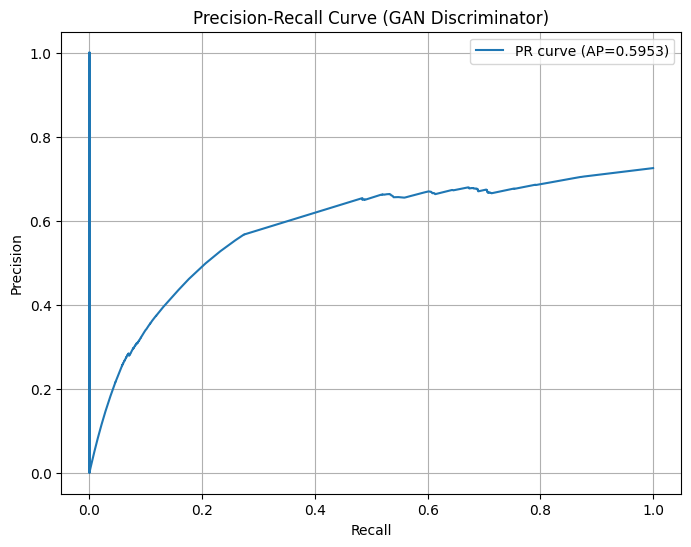

Best threshold: 0.0000
Best F1: 0.8408

Classification Report:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00      7500
           1       0.73      1.00      0.84     19800

    accuracy                           0.73     27300
   macro avg       0.36      0.50      0.42     27300
weighted avg       0.53      0.73      0.61     27300

Confusion Matrix:
[[    0  7500]
 [    0 19800]]


f:\repos\cyber\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
f:\repos\cyber\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
f:\repos\cyber\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


In [15]:

import matplotlib.pyplot as plt

from sklearn.metrics import (
    precision_recall_curve,
    average_precision_score,
    f1_score,
    classification_report,
    confusion_matrix
)


D.eval()

with torch.no_grad():
    scores = torch.sigmoid(D(X_test.to(device))).squeeze().cpu().numpy()


anomaly_score = 1 - scores


precision, recall, thresholds = precision_recall_curve(
    y_test_bin,
    anomaly_score
)

ap = average_precision_score(y_test_bin, anomaly_score)

print(f"Average Precision (AP): {ap:.4f}")


plt.figure(figsize=(8,6))
plt.plot(recall, precision, label=f"PR curve (AP={ap:.4f})")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve (GAN Discriminator)")
plt.legend()
plt.grid()
plt.show()


f1_scores = []

for t in thresholds:
    preds = (anomaly_score >= t).astype(int)
    f1_scores.append(f1_score(y_test_bin, preds))

best_idx = np.argmax(f1_scores)
best_threshold = thresholds[best_idx]

print(f"Best threshold: {best_threshold:.4f}")
print(f"Best F1: {f1_scores[best_idx]:.4f}")


y_pred = (anomaly_score >= best_threshold).astype(int)

print("\nClassification Report:")
print(classification_report(y_test_bin, y_pred))

print("Confusion Matrix:")
print(confusion_matrix(y_test_bin, y_pred))

Me tiré ahí la gráfica Precision Recall de Luchín y claramente esto es peor, dice que el mejor umbral es 0, asique ponerlos todos como ataque. 

Tocará probar entrenar la GAN con el dataset entero (todos los de la clase Benign) y comparar, al igual poniendole 10x más ejemplos va mejor, aunque no creo que se note mucho. 
Otra opción interesante es usar la GAN como extractor de características para pasárselas al AdaBoost, leí que es posible hacerlo y relativamente común.

# CAMBIOS - 04/04

- Escalado de variables antes de entrenar:
- Conversión a tensores después del escalado:
- Quitar la capa Sigmoid del discriminador -> Ahora devuelve **logits** y se usa `BCEWithLogitsLoss`.